In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd

sm = pd.read_csv("../data/processed/germany_social_clean.csv")

ec = pd.read_csv("../data/processed/germany_ecommerce_clean.csv")

# 1 Dataset Overview

# 2 Social Media EDA

# 3 Ecommerce EDA

# 4 Demographic Analysis

# 5 Time Trends

# 6 Education Analysis

# 7 Insights

# 1 Dataset Overview

This section examines the overall structure of the cleaned datasets before exploratory analysis.

Objectives:

- Verify dataset dimensions
- Inspect available variables
- Review data types
- Examine missing values
- Understand distribution of observations

Datasets:

1. Germany Social Media Dataset (`germany_social_clean.csv`)
2. Germany Ecommerce Dataset (`germany_ecommerce_clean.csv`)

### Observation

This step verifies the number of rows and columns in both datasets.

Purpose:

- Confirm successful export from cleaning stage
- Check consistency between social media and ecommerce datasets
- Identify possible row loss during filtering

In [6]:
print("SOCIAL MEDIA DATASET")
print(sm.shape)

print("\nECOMMERCE DATASET")
print(ec.shape)

SOCIAL MEDIA DATASET
(828, 12)

ECOMMERCE DATASET
(288, 12)


### Variable Inspection

This section reviews available variables.

Important analytical variables:

- `year`
- `demo_code`
- `education_level`
- `indicator_name`
- `value`

These variables will be used in later demographic and temporal analysis.

In [7]:
#Check available variables.
sm.columns.tolist()

['demo_code',
 'demographic',
 'demo_type',
 'education_level',
 'indicator_code',
 'indicator_name',
 'country',
 'year',
 'unit',
 'value',
 'obs_flag',
 'missing_flag']

In [8]:
ec.columns.tolist()

['demo_code',
 'demographic',
 'demo_type',
 'education_level',
 'indicator_code',
 'indicator_name',
 'country',
 'year',
 'unit',
 'value',
 'obs_flag',
 'missing_flag']

### Data Types Review

This step checks variable formats.

Expected structure:

- Numeric variables:
    - value
    - year

- Categorical variables:
    - demographic
    - education_level
    - indicator_name

This ensures variables are suitable for aggregation and visualization.

In [9]:
#Data types
sm.info()

<class 'pandas.DataFrame'>
RangeIndex: 828 entries, 0 to 827
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   demo_code        828 non-null    str    
 1   demographic      828 non-null    str    
 2   demo_type        288 non-null    str    
 3   education_level  828 non-null    str    
 4   indicator_code   828 non-null    str    
 5   indicator_name   828 non-null    str    
 6   country          828 non-null    str    
 7   year             828 non-null    int64  
 8   unit             828 non-null    str    
 9   value            828 non-null    float64
 10  obs_flag         60 non-null     str    
 11  missing_flag     288 non-null    object 
dtypes: float64(1), int64(1), object(1), str(9)
memory usage: 77.8+ KB


In [10]:
ec.info()

<class 'pandas.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   demo_code        288 non-null    str    
 1   demographic      288 non-null    str    
 2   demo_type        180 non-null    str    
 3   education_level  288 non-null    str    
 4   indicator_code   288 non-null    str    
 5   indicator_name   288 non-null    str    
 6   country          288 non-null    str    
 7   year             288 non-null    int64  
 8   unit             288 non-null    str    
 9   value            288 non-null    float64
 10  obs_flag         45 non-null     str    
 11  missing_flag     180 non-null    object 
dtypes: float64(1), int64(1), object(1), str(9)
memory usage: 27.1+ KB


### Missing Value Assessment

Purpose:

- Detect incomplete observations
- Verify education labels
- Check indicator availability

Special attention:

The project previously identified non-education segments labelled as:

`Not Education Segment`

These values are intentional and not considered missing data.

### Missing Value Observation

Most analytical variables contain no missing values.

No missing values were found in:

- value
- year
- education_level
- indicator_name
- demographic

Missing values appear mainly in metadata columns:

- obs_flag
- demo_type
- missing_flag

These fields contain Eurostat annotations and do not affect analysis.

In [11]:
#missing value
sm.isnull().sum().sort_values(
ascending=False
)


obs_flag           768
demo_type          540
missing_flag       540
demo_code            0
demographic          0
education_level      0
indicator_code       0
indicator_name       0
country              0
year                 0
unit                 0
value                0
dtype: int64

In [12]:
ec.isnull().sum().sort_values(
ascending=False
)

obs_flag           243
demo_type          108
missing_flag       108
demo_code            0
demographic          0
education_level      0
indicator_code       0
indicator_name       0
country              0
year                 0
unit                 0
value                0
dtype: int64

### Descriptive Statistics

This section summarizes numerical variables.

Key metrics:

- Mean
- Standard deviation
- Minimum
- Maximum

Focus variable:

`value`

This variable represents percentage indicators reported by Eurostat.

In [13]:
#summary statistics
sm.describe(include='all')



,demo_code,demographic,demo_type,education_level,indicator_code,indicator_name,country,year,unit,value,obs_flag,missing_flag
count,828,828,288,828,828,828,828,828.000000,828,828.000000,60,288
unique,12,12,2,4,5,5,1,NaN,2,NaN,2,1
top,Y16_24HI,Individuals aged 16-24 with high formal education,Age,Not Education Segment,I_IUEM,Email Usage,DE,NaN,PC_IND,NaN,b,False
freq,84,84,240,288,180,180,828,NaN,558,NaN,48,288
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.500000,NaN,68.757669,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.708857,NaN,20.317653,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000,NaN,18.050000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.000000,NaN,54.650000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.500000,NaN,71.690000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000,NaN,86.312500,NaN,NaN


In [14]:
ec.describe(include='all')

,demo_code,demographic,demo_type,education_level,indicator_code,indicator_name,country,year,unit,value,obs_flag,missing_flag
count,288,288,180,288,288,288,288,288.000000,288,288.000000,45,180
unique,15,15,3,4,3,3,1,NaN,1,NaN,1,1
top,Y16_24HI,Individuals aged 16-24 with high formal education,Age,Not Education Segment,I_BF_3-5,Moderate Purchase Frequency (3–5 purchases),DE,NaN,PC_IND,NaN,b,False
freq,24,24,144,180,96,96,288,NaN,288,NaN,45,180
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.250000,NaN,15.867292,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.923629,NaN,8.102863,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000,NaN,1.210000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.750000,NaN,9.515000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,NaN,14.420000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.500000,NaN,22.040000,NaN,NaN


## Section 2 — Temporal Coverage

# 2 Temporal Coverage

Check available years and yearly balance.

In [15]:
sorted(
sm['year'].unique()
)

[np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024),
 np.int64(2025)]

In [16]:
sorted(
ec['year'].unique()
)

[np.int64(2020), np.int64(2021), np.int64(2023), np.int64(2025)]

In [17]:
#Year distribution
sm['year'].value_counts().sort_index()

year
2020    138
2021    138
2022    138
2023    138
2024    138
2025    138
Name: count, dtype: int64

In [18]:
ec['year'].value_counts().sort_index()

year
2020    72
2021    72
2023    72
2025    72
Name: count, dtype: int64

## Section 3 — Education Coverage

# Observation:

The education segment counts are not equal between the social media and e-commerce datasets. This is expected because the datasets contain different indicators and different year availability. Social media has broader temporal and indicator coverage, while e-commerce purchase-frequency indicators are available for fewer years. Therefore, row counts should not be directly compared across datasets.

In [19]:
## 3 Education Segments
sm[
'education_level'
].value_counts()

education_level
Not Education Segment    288
High Education           180
Low Education            180
Medium Education         180
Name: count, dtype: int64

In [20]:
ec[
'education_level'
].value_counts()

education_level
Not Education Segment    180
High Education            36
Low Education             36
Medium Education          36
Name: count, dtype: int64

In [21]:
sm.groupby(
['year','education_level']
).size()

year  education_level      
2020  High Education           30
      Low Education            30
      Medium Education         30
      Not Education Segment    48
2021  High Education           30
      Low Education            30
      Medium Education         30
      Not Education Segment    48
2022  High Education           30
      Low Education            30
      Medium Education         30
      Not Education Segment    48
2023  High Education           30
      Low Education            30
      Medium Education         30
      Not Education Segment    48
2024  High Education           30
      Low Education            30
      Medium Education         30
      Not Education Segment    48
2025  High Education           30
      Low Education            30
      Medium Education         30
      Not Education Segment    48
dtype: int64

In [22]:
ec.groupby(
['year','education_level']
).size()

year  education_level      
2020  High Education            9
      Low Education             9
      Medium Education          9
      Not Education Segment    45
2021  High Education            9
      Low Education             9
      Medium Education          9
      Not Education Segment    45
2023  High Education            9
      Low Education             9
      Medium Education          9
      Not Education Segment    45
2025  High Education            9
      Low Education             9
      Medium Education          9
      Not Education Segment    45
dtype: int64

## Section 4 — Indicator Coverage

In [23]:
sm[
'indicator_name'
].value_counts()

indicator_name
Email Usage                   180
Product Information Search    180
Online News Reading           180
Social Media Participation    180
I_IUPH1                       108
Name: count, dtype: int64

In [24]:
ec[
'indicator_name'
].value_counts()

indicator_name
Moderate Purchase Frequency (3–5 purchases)     96
High Purchase Frequency (6–10 purchases)        96
Very High Purchase Frequency (10+ purchases)    96
Name: count, dtype: int64

## Section 5 — Social Media Trend Over Time

# Social Media Trend Analysis

Objective:

Analyze how social media usage changed in Germany from 2020–2025.

This section evaluates yearly trends using average indicator values.

In [25]:
sm_year = sm.groupby(
'year'
)['value'].mean().reset_index()

sm_year

,year,value
0,2020,76.812899
1,2021,63.581667
2,2022,63.896449
3,2023,60.344710
4,2024,73.463986
5,2025,74.446304


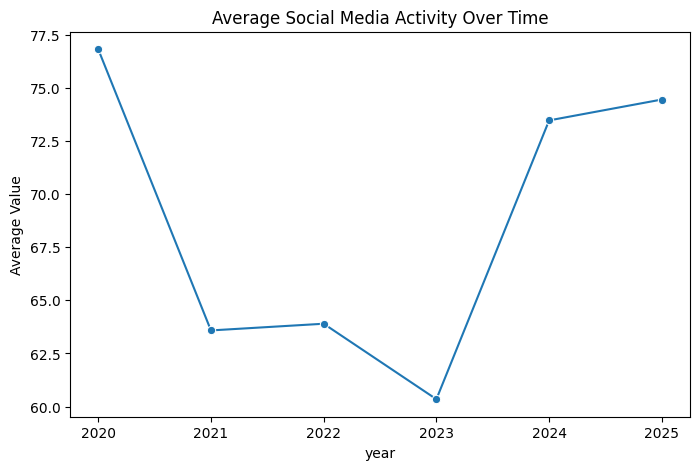

In [26]:
plt.figure(figsize=(8,5))

sns.lineplot(
data=sm_year,
x='year',
y='value',
marker='o'
)

plt.title(
'Average Social Media Activity Over Time'
)

plt.ylabel(
'Average Value'
)

plt.show()

## Section 6 — Ecommerce Trend

# Ecommerce Trend Analysis

Objective:

Examine purchase behavior trends across years.

In [27]:
ec_year = ec.groupby(
'year'
)['value'].mean().reset_index()

ec_year

,year,value
0,2020,18.691667
1,2021,14.215833
2,2023,15.273194
3,2025,15.288472


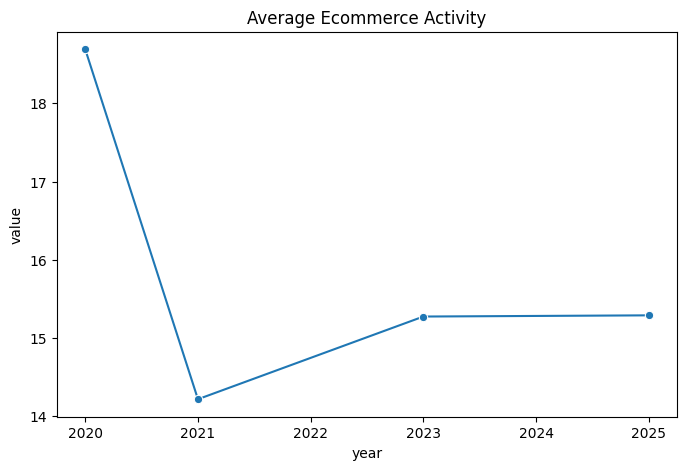

In [28]:
plt.figure(figsize=(8,5))

sns.lineplot(
data=ec_year,
x='year',
y='value',
marker='o'
)

plt.title(
'Average Ecommerce Activity'
)

plt.show()

## Section 7 — Education comparison

# Education Level Comparison

Objective:

Compare digital behavior among education groups.

In [29]:
sm_edu = sm.groupby(
'education_level'
)['value'].mean().reset_index()

sm_edu

,education_level,value
0,High Education,78.671556
1,Low Education,59.207056
2,Medium Education,70.687333
3,Not Education Segment,67.324583


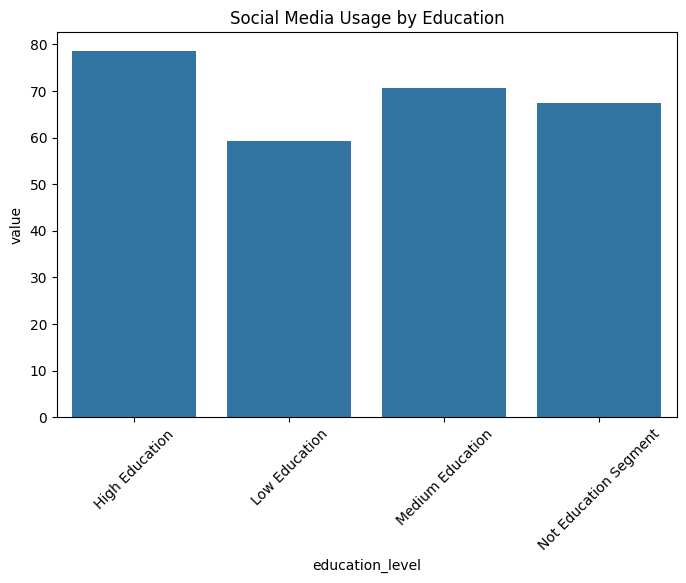

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
data=sm_edu,
x='education_level',
y='value'
)

plt.xticks(rotation=45)

plt.title(
'Social Media Usage by Education'
)

plt.show()

In [31]:
ec_edu = ec.groupby(
'education_level'
)['value'].mean().reset_index()

ec_edu

,education_level,value
0,High Education,21.296111
1,Low Education,9.494722
2,Medium Education,16.735556
3,Not Education Segment,15.882389


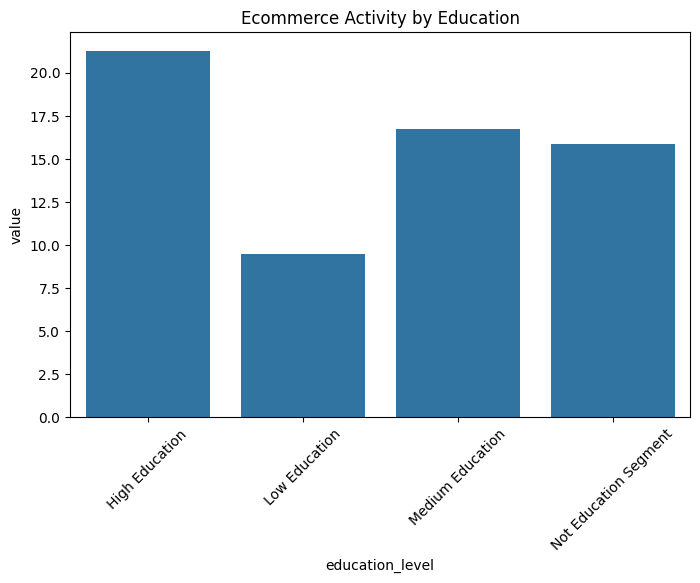

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
data=ec_edu,
x='education_level',
y='value'
)

plt.xticks(rotation=45)

plt.title(
'Ecommerce Activity by Education'
)

plt.show()

## Section 8 — Indicator comparison

In [33]:
sm_indicator = sm.groupby(
'indicator_name'
)['value'].mean().reset_index()

sm_indicator

,indicator_name,value
0,Email Usage,84.855278
1,I_IUPH1,71.640278
2,Online News Reading,62.091222
3,Product Information Search,67.824222
4,Social Media Participation,58.530389


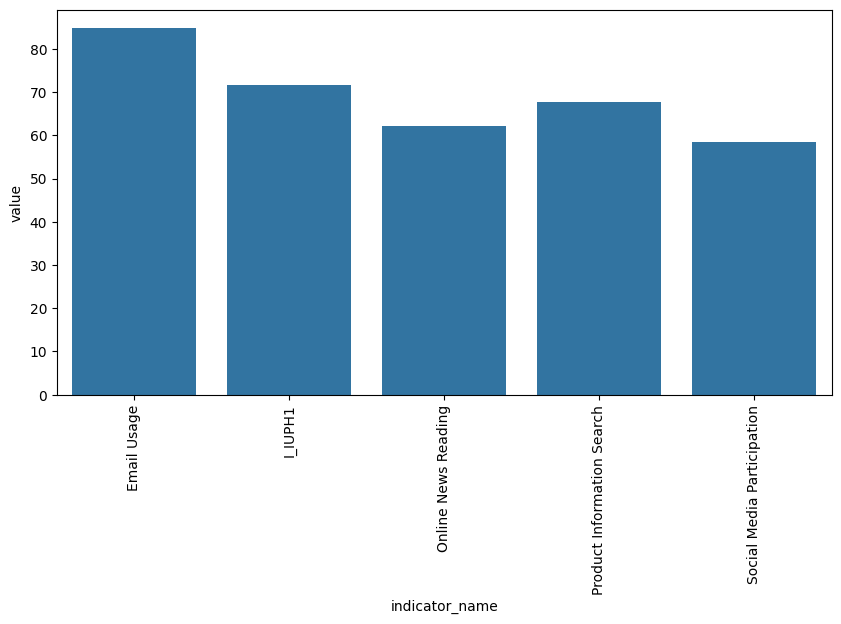

In [34]:
plt.figure(figsize=(10,5))

sns.barplot(
data=sm_indicator,
x='indicator_name',
y='value'
)

plt.xticks(
rotation=90
)

plt.show()

In [35]:
ec_indicator = ec.groupby(
'indicator_name'
)['value'].mean().reset_index()

ec_indicator

,indicator_name,value
0,High Purchase Frequency (6–10 purchases),11.776354
1,Moderate Purchase Frequency (3–5 purchases),23.105000
2,Very High Purchase Frequency (10+ purchases),12.720521


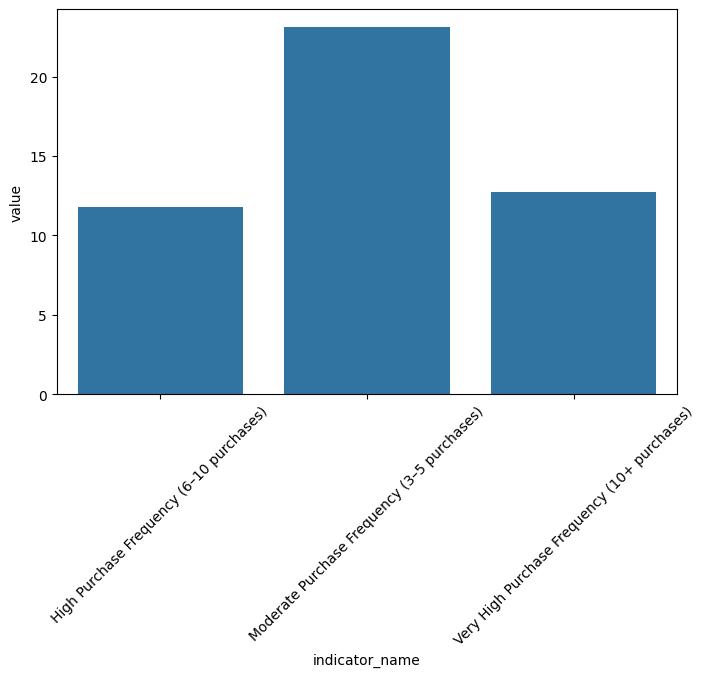

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
data=ec_indicator,
x='indicator_name',
y='value'
)

plt.xticks(rotation=45)

plt.show()

## Section 9 — Distribution

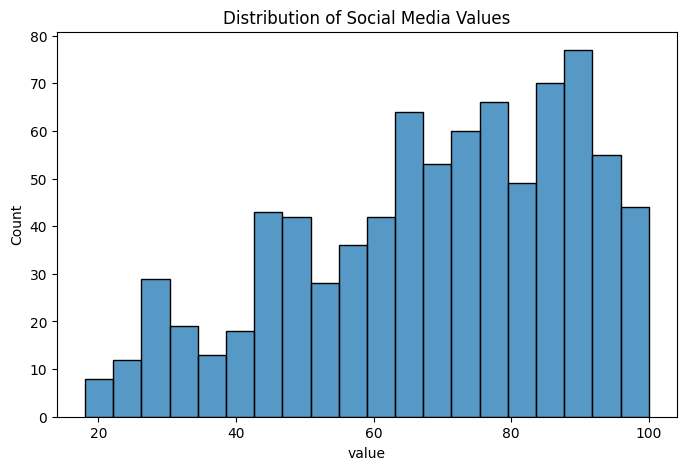

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
sm['value'],
bins=20
)

plt.title(
'Distribution of Social Media Values'
)

plt.show()

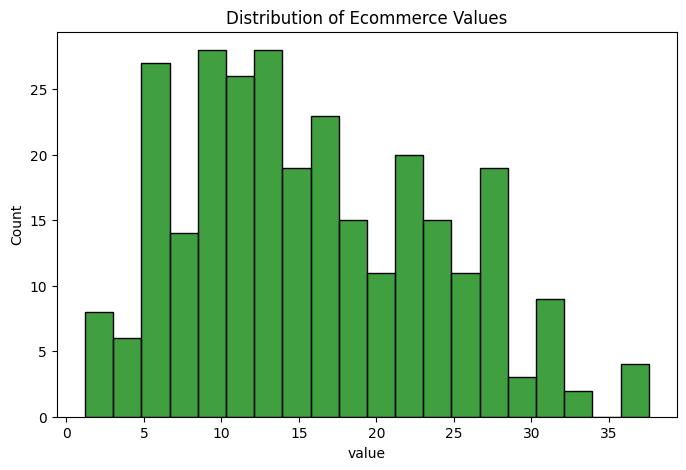

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
ec['value'],
bins=20,
color='green'
)

plt.title(
'Distribution of Ecommerce Values'
)

plt.show()